In [2]:
## importation de la data
from ucimlrepo import fetch_ucirepo
import pandas as pd

# Télécharger le dataset
dataset = fetch_ucirepo(id=544)

# Features (variables d'entrée)
X = dataset.data.features

# Target (variable cible - niveau d'obésité)
y = dataset.data.targets

# Combiner en un seul DataFrame
df = pd.concat([X, y], axis=1)

# Vérifications
print("Dimensions du dataset :", df.shape)
print("\nPremières lignes :")
print(df.head())
print("\nNoms des colonnes :")
print(df.columns.tolist())

Dimensions du dataset : (2111, 17)

Premières lignes :
   Gender   Age  Height  Weight family_history_with_overweight FAVC  FCVC  \
0  Female  21.0    1.62    64.0                            yes   no   2.0   
1  Female  21.0    1.52    56.0                            yes   no   3.0   
2    Male  23.0    1.80    77.0                            yes   no   2.0   
3    Male  27.0    1.80    87.0                             no   no   3.0   
4    Male  22.0    1.78    89.8                             no   no   2.0   

   NCP       CAEC SMOKE  CH2O  SCC  FAF  TUE        CALC  \
0  3.0  Sometimes    no   2.0   no  0.0  1.0          no   
1  3.0  Sometimes   yes   3.0  yes  3.0  0.0   Sometimes   
2  3.0  Sometimes    no   2.0   no  2.0  1.0  Frequently   
3  3.0  Sometimes    no   2.0   no  2.0  0.0  Frequently   
4  1.0  Sometimes    no   2.0   no  0.0  0.0   Sometimes   

                  MTRANS           NObeyesdad  
0  Public_Transportation        Normal_Weight  
1  Public_Transportation 

## 

- **Premières observations** :
  - Les patients sont majoritairement jeunes (21-27 ans)
  - On observe différents niveaux d'obésité dès les premières lignes.
  - Les données semblent propres et bien structurées ✅
  

In [11]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   str    
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   str    
 9   SMOKE                           2111 non-null   str    
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   str    
 12  FAF                             2111 non-null

# Toutes les colonnes ont 2111 non-null → pas de NaN ✅
# Types cohérents : numériques en float64, catégorielles en str ✅
# Mémoire : 280.5 KB → acceptable, pas besoin d'optimiser pour l'EDA
#
# ⚠️ DÉCISION pour data_processing.py :
# Les float64 seront convertis en float32 dans optimize_memory()
# pour réduire la mémoire de ~50% sans perte de précision médicale

In [4]:
print("=== Valeurs manquantes ===")
print(df.isnull().sum())
print(f"\nTotal : {df.isnull().sum().sum()}")

=== Valeurs manquantes ===
Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

Total : 0


# RÉSULTAT OBSERVÉ : 0 valeurs manquantes sur les 17 colonnes ✅
#
# ⚠️ DÉCISION pour data_processing.py :
# Même si le dataset est propre aujourd'hui, on DOIT quand même
# coder handle_missing_values() comme filet de sécurité
# car en production un médecin pourrait ne pas remplir tous les champs
# Stratégie retenue :
#   → Colonnes numériques : imputation par la MÉDIANE (robuste aux outliers)
#   → Colonnes catégorielles : imputation par le MODE (valeur la plus fréquente)

C:\Users\user\AppData\Local\Temp\ipykernel_22736\1761210836.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='NObeyesdad', order=df['NObeyesdad'].value_counts().index, palette='viridis')


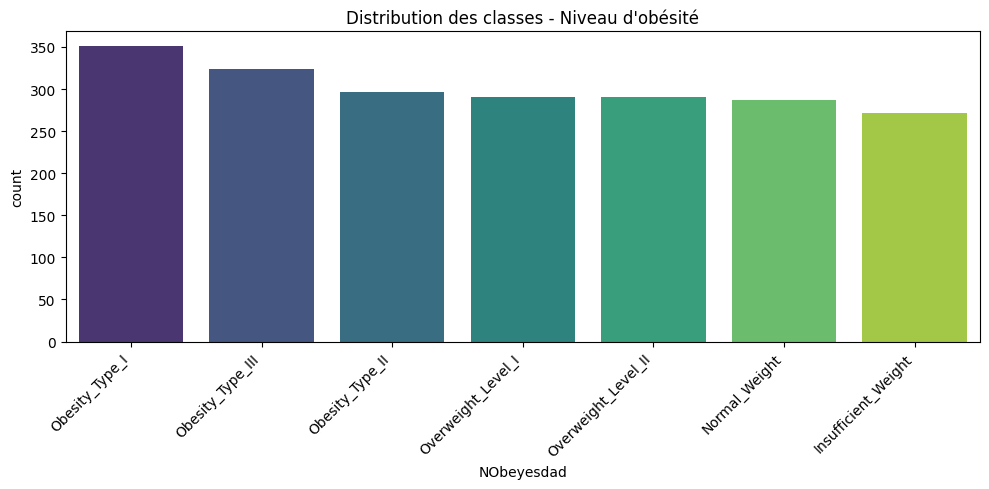

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='NObeyesdad', order=df['NObeyesdad'].value_counts().index, palette='viridis')
plt.title('Distribution des classes - Niveau d\'obésité')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# RÉSULTAT ATTENDU — ce qu'on cherche à voir sur ce graphe :
#
# ✅ Classes quasi-équilibrées (~12-15% chacune sur 7 classes)
#    → PAS besoin de SMOTE ou class_weight sur ce dataset
#    → Si une classe avait < 5% → on aurait dû gérer le déséquilibre
#
# ⚠️ DÉCISION pour train_model.py :
#    → Utiliser stratify=y dans train_test_split()
#       pour que chaque split (train/test) garde la même proportion 12-15%
#    → Ne PAS utiliser class_weight='balanced' dans les modèles
#       car les classes sont déjà équilibrées
#
# ⚠️ DÉCISION pour evaluate_model.py :
#    → Utiliser F1-MACRO (donne le même poids à chaque classe)
#       plutôt que F1-weighted (qui avantagerait les classes majoritaires)
#    → La confusion matrix montrera si certaines classes voisines
#       sont confondues (ex: Overweight_I vs Overweight_II)
#       ce qui est médicalement acceptable mais à surveiller



C:\Users\user\AppData\Local\Temp\ipykernel_22736\3267602486.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=df[col], palette='viridis')
C:\Users\user\AppData\Local\Temp\ipykernel_22736\3267602486.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=df[col], palette='viridis')
C:\Users\user\AppData\Local\Temp\ipykernel_22736\3267602486.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=df[col], palette='viridis')
C:\Users\user\AppData\Local\Temp\ipykernel_22736\3267602486.py:10: FutureWarning: 

Passing `palette` without assignin

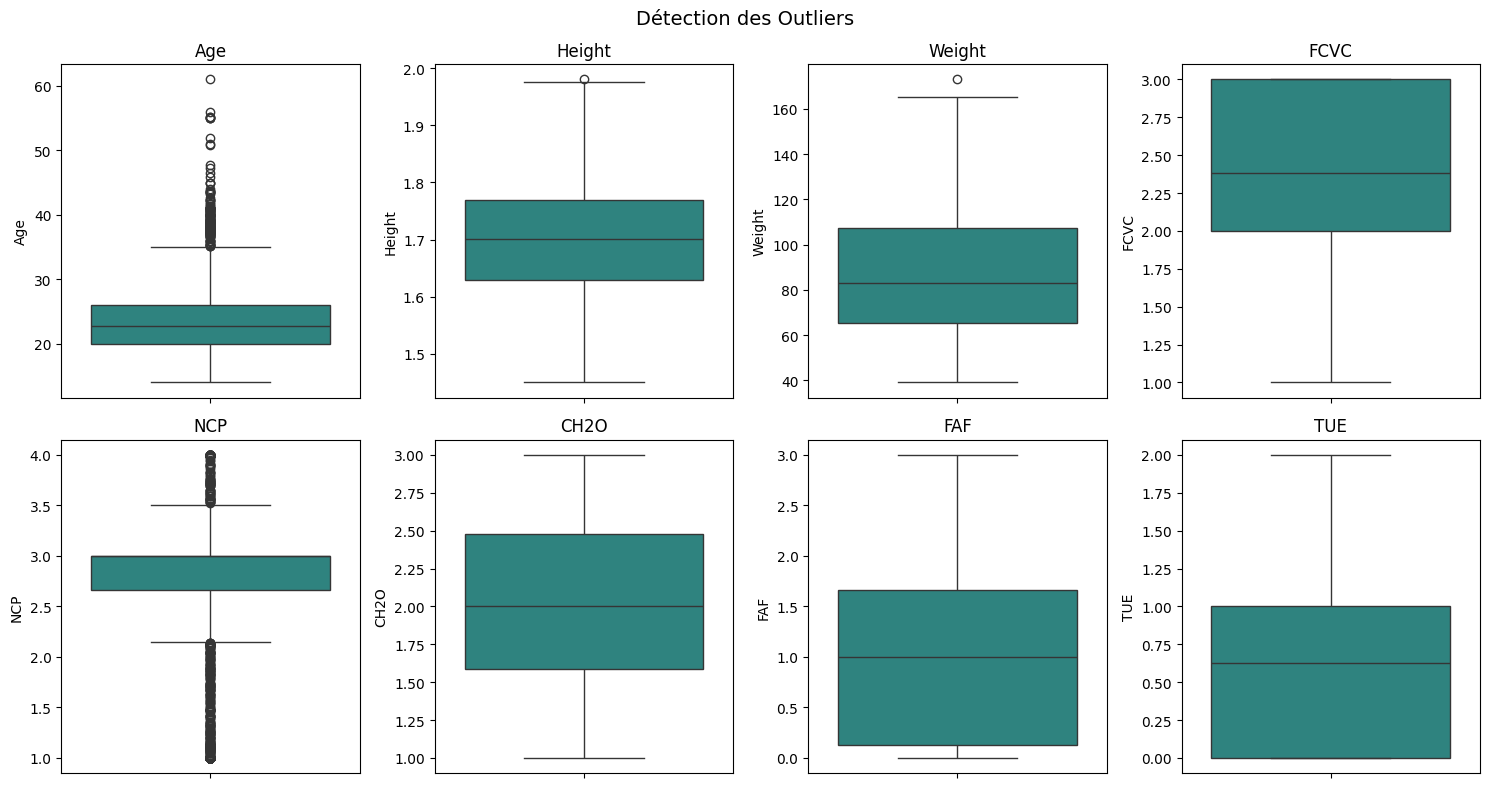

In [9]:
# ============================================
# 4. OUTLIERS - Boxplots
# ============================================

numerical_cols = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']

plt.figure(figsize=(15, 8))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 4, i+1)
    sns.boxplot(y=df[col], palette='viridis')
    plt.title(col)
plt.suptitle('Détection des Outliers', fontsize=14)
plt.tight_layout()
plt.show()

## ✅ Conclusion - Outliers

- **Age** : quelques patients âgés (50-61 ans) → valeurs médicalement normales ✅
- **Height** : 1 patient très grand (1.98m) → valeur normale ✅
- **Weight** : 1 patient très lourd (170kg) → valeur normale ✅
- **NCP** : certains patients mangent 1 seul repas/jour → comportement possible ✅

**Stratégie** : Aucun outlier supprimé — toutes les valeurs sont médicalement plausibles.

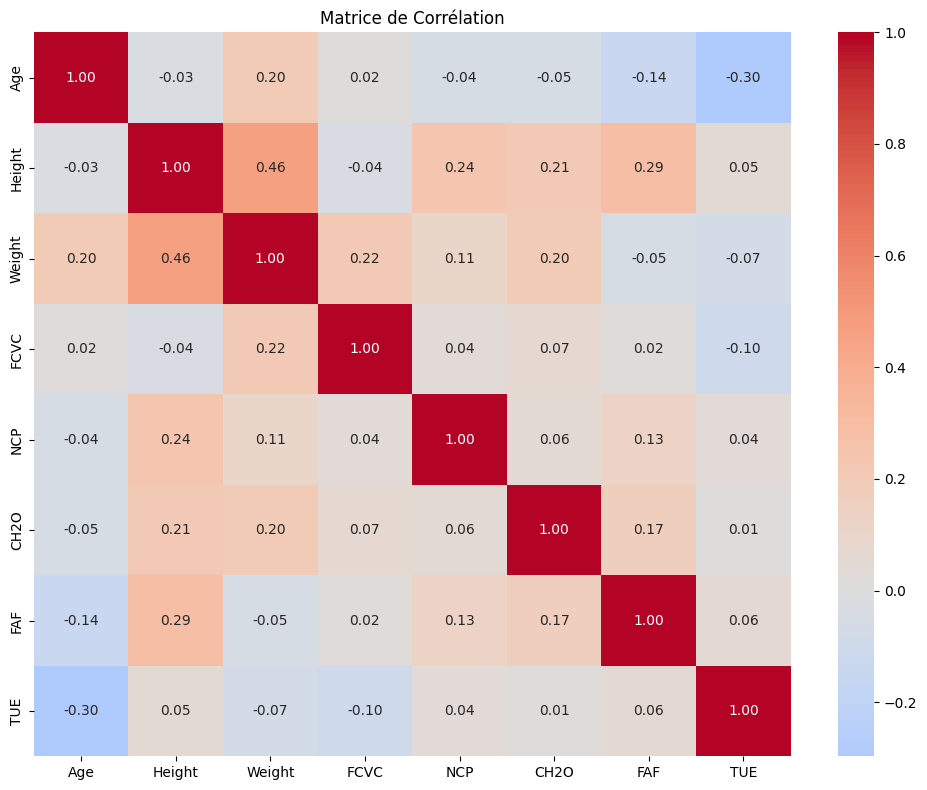

In [10]:
# ============================================
# 5. CORRÉLATIONS
# ============================================
# Ce code calcule la relation entre chaque paire de colonnes numériques
# Une corrélation proche de 1 ou -1 = très liées
# Une corrélation proche de 0 = pas de relation

plt.figure(figsize=(10, 8))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, 
            annot=True,      # affiche les valeurs dans chaque case
            fmt='.2f',       # arrondi à 2 décimales
            cmap='coolwarm', # rouge = corrélation positive, bleu = négative
            center=0)
plt.title('Matrice de Corrélation')
plt.tight_layout()
plt.show()


## ✅ Conclusion - Corrélations

| Paire | Corrélation | Interprétation |
|-------|------------|----------------|
| Height ↔ Weight | 0.46 | Normal biologiquement |
| Age ↔ TUE | -0.30 | Les personnes âgées utilisent moins les écrans |
| Height ↔ FAF | 0.29 | Les personnes grandes font légèrement plus de sport |

**Stratégie** : Aucune corrélation forte (> 0.8) détectée → toutes les colonnes sont conservées.